<div class="alert alert-block alert-success">
<h1> Machine Learning - Project Cars4You</h1>
<h2> 2 - Holdout Method, Preprocessing & Feature Selection <h2>
<h2> Group 36 </h2>
<h3> 20225/2026 </h3>

***

## **Table of Contents**<br>

[1. **Importing libraries & Data**](#1-Importing-libraries-&-Data)<br>

[2. Train-test Split](#2-Train-test-Split)<br>

[3. Feature Engineering](#3-Feature-Engineeering)<br>
- [3.1 Encoding](#31-Encoding)<br>
- [3.2 Missing Values](#32-Missing-Values)<br>
    - [3.2.1 Dealing with Missing Values](#221-Dealing-with-Missing-Values)<br>
- [3.3 Outliers](#33-Outliers)<br>
    - [3.3.1 Outliers detection](#331-Outliers-detection)<br>
    - [3.3.2 Dealing with outliers](#332-Dealing-with-outliers)<br>
- [3.4 Scaling](#34-Scaling)<br>
    
[4 Feature Selection](#4-Feature-Selection)<br>

[5 Export](#5-Export)<br>
    

***

This notebook will consist of Feature Engineering and Selection, after Train-Test Split.

> Student Name - Artem Polikarpov
>> 20250443

> Student Name - Diogo Montenegro
>> 20250491

> Student Name - Francisco Martins
>> 20250482

> Student Name - João Cardoso
>> 20240529 


***

# 1. Import Libraries & Data

Import core libraries + sklearn utilities.

In [1]:
# --- General scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
sns.set()


# --- Data partition ---
from sklearn.model_selection import train_test_split


# --- Filter methods (stats) ---
# - Spearman (rank-based, robust to skew/outliers)
# - Chi-square (categorical vs target discretizations)
import scipy.stats as stats
from scipy.stats import chi2_contingency


# --- Wrappers / estimators ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, TargetEncoder

from sklearn.model_selection import PredefinedSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import (
mean_absolute_error,
r2_score, mean_absolute_error, mean_squared_error,
median_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
)
from sklearn.impute import KNNImputer, SimpleImputer

# --- Embedded methods ---
from sklearn.linear_model import LassoCV, Lasso


# --- Scalers ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


# --- Housekeeping ---
import warnings
warnings.filterwarnings('ignore')


# --- Custom helpers (plotting/outlier) ---
from functions_2 import (
histogram_boxplot, labeled_barplot, stacked_barplot,
distribution_plot_wrt_target, comparative_boxplot, comparative_barplot,
detect_outliers_iqr,plot_feature_importance, plot_importance, cor_heatmap, TestIndependence
)


# Optional mapping used elsewhere in the project (kept for consistency)
from Inconsistencies_vocab_func import BRAND_MODEL_VOCAB


# --- Reproducibility ---
RSEED = 42
np.random.seed(RSEED)
pd.set_option('display.max_rows', 500)


### **Initial disclaimer** 
On this notebook, every change or analysis that we might do, we are not going to take in consideration the features `hasDamage`and `paintQuality%` since that, in the context of our project, these features are meaningless. The true value of these features can only be obtained after visiting a mechanic, and since we are trying to develop a method to predict car prices without visiting a mechanic, we decided not to include these features. 

#### Data Loading

Load **pre-cleaned** train and test sets coming from the EDA/preprocessing notebook.

In [2]:
train = pd.read_csv('../project_data/train_data_EDA.csv', index_col = 0)

test = pd.read_csv('../project_data/test_data_EDA.csv', index_col = 0)

# 2. Train-Test Split

**Holdout Method** — we create a fixed **validation set** to compare feature sets and models quickly.

In [3]:
# Split the DataFrame into features (X) and target variable (y)
X = train.drop('price', axis=1) 
y = train['price']  

In [4]:
# Holdout split: 80% train / 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=0) 

We decided to split into 80% train and the other 20% for validation.

# 3. Feature Engineering

## 3.1 Encoding

Categorical Variables = "Brand","model","transmission","fuelType", but since we have already encoded "Brand", "transmission" and "fueltype", only "model" lefts

***model*** → target endoding **mean price per model**

In [5]:
X_train_enc = X_train.copy()
X_val_enc   = X_val.copy()

mean_price_by_model = y_train.groupby(X_train_enc['model']).mean()

global_mean_price = y_train.mean()

X_train_enc['model_te'] = X_train_enc['model'].map(mean_price_by_model)

X_val_enc['model_te'] = X_val_enc['model'].map(mean_price_by_model)

X_val_enc['model_te'] = X_val_enc['model_te'].fillna(global_mean_price)

X_train = X_train_enc.drop(columns=['model'])
X_val   = X_val_enc.drop(columns=['model'])

test['model_te'] = test['model'].map(mean_price_by_model)
test['model_te'] = test['model_te'].fillna(global_mean_price)
test_encoded = test.drop(columns=['model'])

***Disclaimer*** -> We tried to apply the `"TargetEncoder()"` function from the scikit-learn library but, for some reason, the parameters we were trying to use did not exist, even after searching on https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html

<h2>Apply binning on tax

As we mentioned in the previous notebook, we observed that `"tax" is very skewed` so we decided to devide it into different **bins**, that we found meaningfull.

First, we must replace the missing `tax` values so we decided to find the **median tax value per model** and replace the missing values by its tax median for its model.
For unknown models, we replace the missing value by a tax global median.

In [6]:
#tax median by model
tax_median_by_model = X_train.groupby('model_te')['tax'].median()

#global median for entries not in any group
global_tax_median = X_train['tax'].median()

def impute_tax_by_model(df):
    df = df.copy()
    #Fill Nan with the median tax of the model_te
    df['tax'] = df['tax'].fillna(df['model_te'].map(tax_median_by_model))
    #If there is still any Nan or if model_te did not exist
    df['tax'] = df['tax'].fillna(global_tax_median)
    return df

After learning on train, we impute the missing values on every dataframe.

In [7]:
X_train = impute_tax_by_model(X_train)
X_val   = impute_tax_by_model(X_val)
test_encoded = impute_tax_by_model(test_encoded)


As we can observe in the boxplot below, whe can see that there is an high density of values in different ranges. For example, we can easily see that there are **many tax values = 0** so we can separate those into a single bin. Then, we can see that **between 1-100**, we also find a big amount of values, so we can put them all together in the second bin. Then, for the third bin, we decided to group all the **non outliers values**, values **bewtween 101 and 170**. For the last two bins, we decided to grab all the values from **171 until 450** and group them all together and, finnaly, group all the extreme outliers, values **equal or above 451**.

Column: tax - Number of Outliers: 16054
Column: tax - % of Outliers: 26.41%



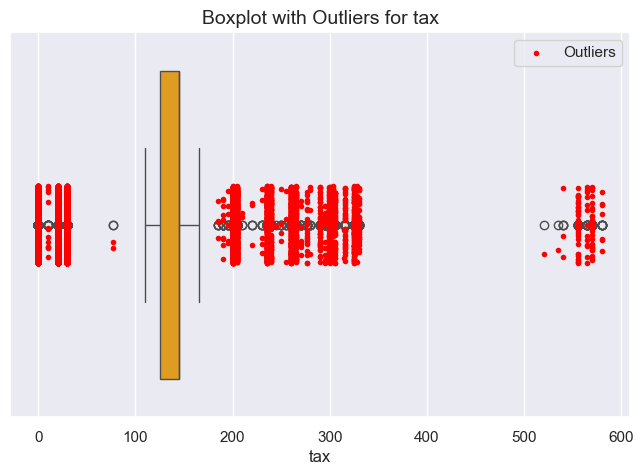

,Column,Num_Outliers,Pct_Outliers
0,tax,16054,26.414163


In [10]:
detect_outliers_iqr(X_train[['tax']], threshold=0.001)

In [141]:
bins   = [-0.1, 0.1, 100, 170, 450, float('inf')]
labels = ['0', '1_100', '101_170', '171_450', '451_plus']

X_train['tax_bin'] = pd.cut(X_train['tax'], bins=bins, labels=labels)
X_val['tax_bin']   = pd.cut(X_val['tax'],   bins=bins, labels=labels)
test_encoded['tax_bin']  = pd.cut(test_encoded['tax'],  bins=bins, labels=labels)


In [142]:
X_train = X_train.drop(columns=['tax'])
X_val   = X_val.drop(columns=['tax'])
test_encoded  = test_encoded.drop(columns=['tax'])

Finnaly, we applied the changes told above, replacing the `tax` values by the label that represents the range of that particular value. We also droped the column tax, since from now on we are only going to work with binning tax.

In [143]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
tax_train_ohe = ohe.fit_transform(X_train[['tax_bin']])
tax_val_ohe   = ohe.transform(X_val[['tax_bin']])
tax_test_ohe  = ohe.transform(test_encoded[['tax_bin']])


In [144]:
#obtain the name of the new columns (one per bin)
tax_ohe_cols = ohe.get_feature_names_out(['tax_bin'])

#convert the array intoa df, aligned by the index of X_train
tax_train_df = pd.DataFrame(
    tax_train_ohe,
    columns=tax_ohe_cols,
    index=X_train.index      
)
#remove the old column 'tax_bin' and add the new dummies
X_train = pd.concat(
    [X_train.drop(columns=['tax_bin']), tax_train_df],
    axis=1
)

In [145]:
tax_val_ohe = ohe.transform(X_val[['tax_bin']])
tax_val_df  = pd.DataFrame(tax_val_ohe, columns=tax_ohe_cols, index=X_val.index)

X_val = pd.concat(
    [X_val.drop(columns=['tax_bin']), tax_val_df],
    axis=1
)

In [146]:
tax_test_ohe = ohe.transform(test_encoded[['tax_bin']])
tax_test_df  = pd.DataFrame(tax_test_ohe, columns=tax_ohe_cols, index=test_encoded.index)

test_encoded = pd.concat(
    [test_encoded.drop(columns=['tax_bin']), tax_test_df],
    axis=1
)

So now, we have our dataframes with the new binned columns.

## 3.3 Outliers
In this section, we decided not only to infer, but also to `take action on the outlier existance`.

We flag obvious anomalies but keep realistic extremes (e.g., high mileage) to avoid biasing the used-car market tails.

### 3.3.1 Outlier detection

Outlier detection — IQR rule (very small threshold just for inspection)

Column: mileage - Number of Outliers: 2603
Column: mileage - % of Outliers: 4.28%



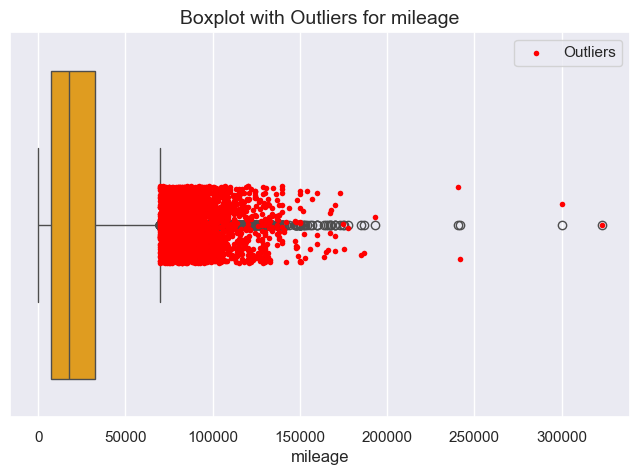

Column: mpg - Number of Outliers: 922
Column: mpg - % of Outliers: 1.52%



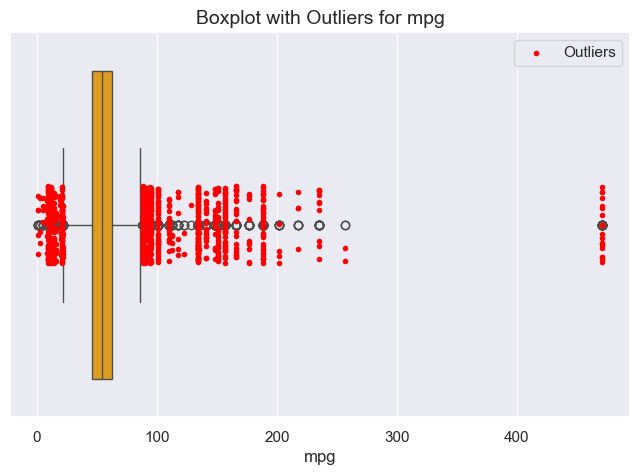

Column: engineSize - Number of Outliers: 494
Column: engineSize - % of Outliers: 0.81%



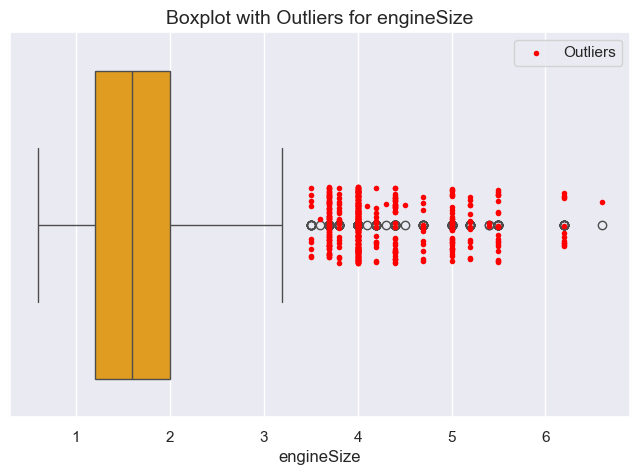

Column: paintQuality% - Number of Outliers: 0
Column: paintQuality% - % of Outliers: 0.00%



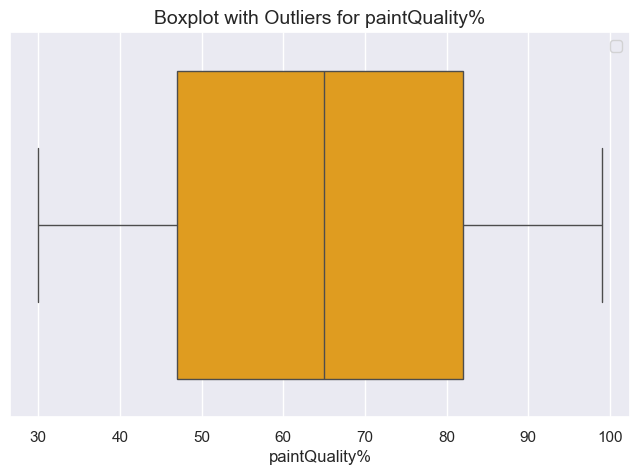

Column: previousOwners - Number of Outliers: 0
Column: previousOwners - % of Outliers: 0.00%



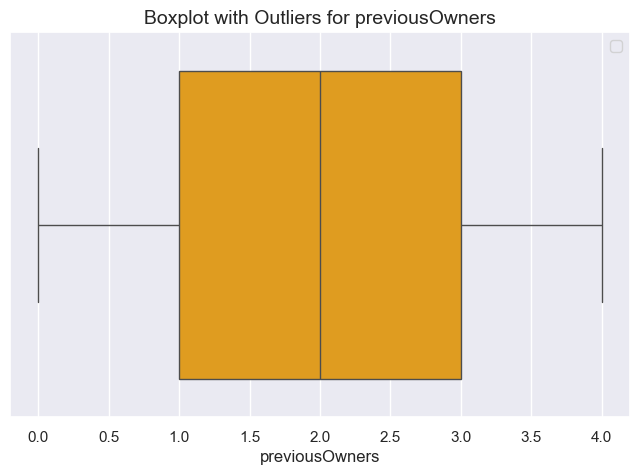

Column: carAge - Number of Outliers: 1334
Column: carAge - % of Outliers: 2.19%



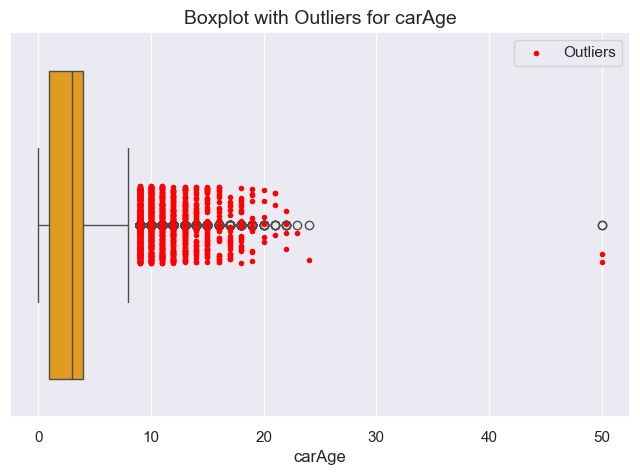

,Column,Num_Outliers,Pct_Outliers
0,mileage,2603,4.282800
1,mpg,922,1.516996
2,engineSize,494,0.812794
3,carAge,1334,2.194873


In [12]:
#This helper prints potential outliers per numeric column; used for manual review we don't automatically remove them here.
detect_outliers_iqr(X_train[['mileage','mpg','engineSize','paintQuality%','previousOwners','carAge']], threshold=0.001)

### 3.3.2 Dealing with outliers

Case-by-case review

***mileage*** 

As we can see, only 4% of the observations are outliers. Just by taking a look to the boxplot and the highlighting outliers, we can manually define a trehsold on 200000, since we can see a huge accumulation of outliers with values lower than 200000 and only 4 are greater than 200000.

Let's then take a look into the car details of the ones that have mileage greater than 200000.

In [148]:
X_train[X_train['mileage'] > 200000]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
4840,300000.0,57.6,1.9,2.0,10.0,79.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48382,13918.386449,0.0,1.0,0.0,0.0,0.0
6658,323000.0,44.1,2.0,1.0,12.0,74.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4692,22732.945596,0.0,0.0,1.0,0.0,0.0
33484,241565.0,47.9,1.9,4.0,NaN,33.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48912,13918.386449,0.0,0.0,1.0,0.0,0.0
6435,240494.0,68.9,2.1,4.0,4.0,81.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,39946,19859.591539,0.0,0.0,0.0,1.0,0.0


Since having more than 300000+ miles in 10+ years is completely possible, we will not treat them as wrong values.
However, we can see that there is a car with 4 years of age and 240494 miles registered. Even being weird, we do not consider this value as unreal, since sometimes there are people that do not work in the city that they live, so they have to drive many miles just to get to work.

***mpg*** 

Only 1.5% of the values are outliers. Again, just by looking to the highlighting outliers, we can easily observe some weird values.
In first place, we can see that are many cars with mpg's values lower than 5, which is impossible. If we would consider those values as feaseble, we would be considering that a car, after using up all the fuel in the tank, the car would have traveled only a few miles, which is unreal. 

Then, we can see that are many values in the range of 100 and 200 that are very well compacted, however, we can observe that we have some mpg values greater than 200, so we must take them into consideration.


In [149]:
X_train[X_train['mpg']<=5]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
41175,4.0,2.8,2.4,0.0,1.0,78.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,52171,20406.020000,0.0,0.0,1.0,0.0,0.0
59587,5213.0,1.1,1.6,2.0,0.0,92.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,32600,18261.802548,0.0,1.0,0.0,0.0,0.0
14507,1259.0,2.8,2.4,2.0,0.0,54.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,54731,20406.020000,0.0,0.0,1.0,0.0,0.0
21182,100.0,2.8,2.4,1.0,0.0,56.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,53904,20406.020000,0.0,0.0,1.0,0.0,0.0
56384,1290.0,1.1,1.6,4.0,0.0,71.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,34501,18261.802548,0.0,1.0,0.0,0.0,0.0
11079,2844.0,1.1,1.6,3.0,1.0,53.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,31981,18261.802548,0.0,1.0,0.0,0.0,0.0
2454,4000.0,1.1,1.3,2.0,0.0,37.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,43194,19859.591539,0.0,1.0,0.0,0.0,0.0
7524,1000.0,1.1,1.3,2.0,0.0,93.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,46208,19859.591539,0.0,1.0,0.0,0.0,0.0


As we can see, 3 different types of car models have mpg values equal or lower than 5.
Let's take a deeper look into those models.

In [150]:
X_train[X_train['model_te']==20406.02].sample(10)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
11270,61000.0,32.8,3.0,4.0,6.0,47.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,53759,20406.02,0.0,0.0,1.0,0.0,0.0
75302,34868.0,40.4,2.4,4.0,2.0,30.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,52329,20406.02,0.0,0.0,1.0,0.0,0.0
20523,12276.0,36.2,2.4,0.0,2.0,61.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,53640,20406.02,0.0,0.0,1.0,0.0,0.0
3869,11517.0,36.2,2.4,3.0,3.0,49.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,51625,20406.02,0.0,0.0,1.0,0.0,0.0
2634,6500.0,40.4,2.4,0.0,1.0,72.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,54749,20406.02,0.0,0.0,1.0,0.0,0.0
19331,NaN,36.2,2.4,0.0,NaN,88.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,54299,20406.02,0.0,0.0,1.0,0.0,0.0
75503,92007.0,32.8,3.0,2.0,7.0,80.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,51934,20406.02,0.0,0.0,1.0,0.0,0.0
70053,57932.0,40.4,2.4,2.0,3.0,66.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,54144,20406.02,0.0,0.0,1.0,0.0,0.0
67268,16000.0,36.2,2.4,3.0,2.0,95.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,54471,20406.02,0.0,0.0,1.0,0.0,0.0
56459,35855.0,36.2,2.4,4.0,3.0,59.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,55517,20406.02,0.0,0.0,1.0,0.0,0.0


As we can see, having a value lower than 5 mpg it is unreal, at least for this specific model

In [151]:
X_train[np.isclose(X_train['model_te'], 18261.802548, atol=1e-6)].sample(10)
#we had to proceed like this because the model_te shown in the previous cell, it is not the full float number that is storage in memory.

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
62200,7999.0,78.5,1.6,4.0,2.0,55.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,33682,18261.802548,0.0,1.0,0.0,0.0,0.0
14992,5.0,62.8,1.6,3.0,0.0,98.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,34093,18261.802548,0.0,1.0,0.0,0.0,0.0
52506,24905.0,78.5,1.6,3.0,2.0,38.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,31983,18261.802548,0.0,1.0,0.0,0.0,0.0
3992,10.0,78.5,1.6,1.0,1.0,38.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,31692,18261.802548,0.0,1.0,0.0,0.0,0.0
24408,32360.0,78.5,1.6,1.0,2.0,NaN,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,32056,18261.802548,0.0,1.0,0.0,0.0,0.0
39548,9950.0,78.5,1.6,4.0,1.0,93.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,34500,18261.802548,0.0,1.0,0.0,0.0,0.0
56384,1290.0,1.1,1.6,4.0,0.0,71.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,34501,18261.802548,0.0,1.0,0.0,0.0,0.0
59587,5213.0,1.1,1.6,2.0,0.0,92.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,32600,18261.802548,0.0,1.0,0.0,0.0,0.0
71271,11591.0,78.5,1.6,4.0,2.0,48.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,32467,18261.802548,0.0,1.0,0.0,0.0,0.0
50253,55190.0,78.5,1.6,0.0,9.0,89.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,32575,18261.802548,0.0,1.0,0.0,0.0,0.0


For this model, we can make the same conclusion as the above.

In [152]:
X_train[np.isclose(X_train['model_te'], 19859.591539, atol=1e-6)].sample(10)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
17384,5282.0,53.3,1.3,NaN,1.0,81.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,35796,19859.591539,0.0,1.0,0.0,0.0,0.0
50103,3189.0,47.9,1.3,1.0,1.0,53.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,37202,19859.591539,0.0,1.0,0.0,0.0,0.0
66573,34758.0,65.7,2.1,2.0,3.0,64.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,46008,19859.591539,0.0,1.0,0.0,0.0,0.0
13450,NaN,68.9,2.1,0.0,4.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,39289,19859.591539,0.0,0.0,0.0,1.0,0.0
51641,19596.0,68.9,1.5,3.0,4.0,50.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40916,19859.591539,0.0,0.0,0.0,1.0,0.0
65845,2563.0,53.3,1.3,3.0,0.0,87.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,42197,19859.591539,0.0,1.0,0.0,0.0,0.0
67277,27654.0,72.4,1.5,2.0,3.0,38.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,36787,19859.591539,0.0,1.0,0.0,0.0,0.0
71901,86706.0,53.3,1.3,4.0,1.0,97.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,44739,19859.591539,0.0,1.0,0.0,0.0,0.0
20047,17855.0,72.4,1.5,2.0,3.0,31.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,39746,19859.591539,0.0,1.0,0.0,0.0,0.0
58507,14645.0,68.9,2.1,0.0,2.0,82.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,38847,19859.591539,0.0,1.0,0.0,0.0,0.0


So, since we consider that mpg<5 is unreal, we are going to replace them by `Nan`, to impute all the missing values in the future.

In [153]:
X_train.loc[X_train['mpg'] < 5, 'mpg'] = np.nan
X_val.loc[X_val['mpg'] < 5, 'mpg'] = np.nan
test_encoded.loc[test_encoded['mpg'] < 5, 'mpg'] = np.nan

All the changes applied to train, validation and test datasets.

Now, let's deal with the outliers with high values.

First, let's just check the group of the highest mpg values. As observed before, we can see that there are many observation with mpg values grater than 400.

In [154]:
X_train[X_train['mpg']>400]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
54333,NaN,470.8,0.6,4.0,3.0,95.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,10133,18574.947368,1.0,0.0,0.0,0.0,0.0
70578,19995.0,470.8,NaN,3.0,4.0,79.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,9196,18574.947368,1.0,0.0,0.0,0.0,0.0
4101,33931.0,470.8,NaN,4.0,5.0,31.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,13075,18574.947368,1.0,0.0,0.0,0.0,0.0
46823,43695.0,470.8,NaN,1.0,4.0,81.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,11068,18574.947368,1.0,0.0,0.0,0.0,0.0
48149,36429.0,470.8,NaN,2.0,3.0,30.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,14531,18574.947368,1.0,0.0,0.0,0.0,0.0
50071,65800.0,470.8,NaN,3.0,5.0,50.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,12332,18574.947368,1.0,0.0,0.0,0.0,0.0
63762,20929.0,470.8,NaN,2.0,3.0,71.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,9643,18574.947368,0.0,1.0,0.0,0.0,0.0
5278,23956.0,470.8,0.6,1.0,3.0,53.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,12640,18574.947368,0.0,1.0,0.0,0.0,0.0
29581,26965.0,470.8,NaN,3.0,3.0,81.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,12269,18574.947368,0.0,1.0,0.0,0.0,0.0
24975,9886.0,470.8,NaN,0.0,5.0,44.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,13378,18574.947368,1.0,0.0,0.0,0.0,0.0


Even that, in majority, they are all from the same model, we should consider them as wrong since, after searching, we can conclude that it is completely impossible for a car to have a mpg value greater than 400. So, we are also going to replace these values by `Nan`and inpute them in the future.

In [155]:
X_train.loc[X_train['mpg'] > 400, 'mpg'] = np.nan
X_val.loc[X_val['mpg'] > 400, 'mpg'] = np.nan
test_encoded.loc[test_encoded['mpg'] > 400, 'mpg'] = np.nan

Let's now take a look for the mpg values greater than 200.

In [156]:
X_train[X_train['mpg']>200]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
17247,5000.0,201.8,1.4,0.0,0.0,48.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,50564,19205.198565,0.0,1.0,0.0,0.0,0.0
4191,14886.0,256.8,1.6,4.0,2.0,39.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,31699,18261.802548,0.0,1.0,0.0,0.0,0.0
39175,1500.0,235.0,1.8,4.0,0.0,36.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,51387,18994.213793,0.0,1.0,0.0,0.0,0.0
59959,9975.0,217.3,1.8,3.0,1.0,57.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,52742,18994.213793,0.0,1.0,0.0,0.0,0.0
45755,6552.0,235.0,1.8,1.0,1.0,69.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,54503,18994.213793,0.0,1.0,0.0,0.0,0.0
72900,4129.0,201.8,2.0,0.0,1.0,57.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,36609,25544.600000,0.0,1.0,0.0,0.0,0.0
61955,NaN,235.0,1.8,0.0,2.0,47.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,51312,18994.213793,0.0,1.0,0.0,0.0,0.0
34200,7386.0,256.8,1.6,2.0,1.0,53.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,31790,18261.802548,0.0,1.0,0.0,0.0,0.0
57271,NaN,217.3,1.8,2.0,1.0,37.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,52743,18994.213793,0.0,1.0,0.0,0.0,0.0
4935,400.0,217.3,2.0,0.0,0.0,66.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,44875,23717.490289,0.0,1.0,0.0,0.0,0.0


Let's see each model individually to conclude if these mpg values are weird or not.

In [157]:
X_train[np.isclose(X_train['model_te'],15835.985185, atol=1e-6)].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
1142,6829.0,38.2,1.5,2.0,3.0,59.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,29926,15835.985185,0.0,1.0,0.0,0.0,0.0
15717,23698.0,45.6,1.5,1.0,3.0,52.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,16168,15835.985185,0.0,1.0,0.0,0.0,0.0
61565,32713.0,54.3,2.0,3.0,2.0,80.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,29146,15835.985185,0.0,1.0,0.0,0.0,0.0
21580,15782.0,64.2,1.5,4.0,4.0,69.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,29761,15835.985185,0.0,0.0,0.0,1.0,0.0
3679,33749.0,60.1,2.0,4.0,5.0,49.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,19306,15835.985185,0.0,1.0,0.0,0.0,0.0


In [158]:
X_train[np.isclose(X_train['model_te'],23717.490289	 , atol=1e-6)].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
39589,NaN,65.7,3.7,3.0,4.0,63.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,35812,23717.490289,0.0,0.0,0.0,1.0,0.0
39350,14085.0,56.5,2.0,3.0,2.0,47.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,37648,23717.490289,0.0,1.0,0.0,0.0,0.0
63810,2584.0,NaN,2.0,3.0,1.0,NaN,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,43034,23717.490289,0.0,1.0,0.0,0.0,0.0
47434,7926.0,57.7,2.0,4.0,1.0,47.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,41843,23717.490289,0.0,1.0,0.0,0.0,0.0
37711,4910.0,40.9,2.0,3.0,3.0,72.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,45115,23717.490289,0.0,1.0,0.0,0.0,0.0


In [159]:
X_train[X_train['model_te']==25544.600000].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
66330,73000.0,32.5,1.8,4.0,15.0,83.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,44732,25544.6,0.0,0.0,1.0,0.0,0.0
69468,28491.0,72.4,2.0,3.0,3.0,51.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,35694,25544.6,0.0,0.0,0.0,1.0,0.0
64811,6940.0,48.7,3.0,2.0,1.0,96.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40667,25544.6,0.0,1.0,0.0,0.0,0.0
52514,18060.0,61.4,2.0,0.0,NaN,85.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,44390,25544.6,0.0,1.0,0.0,0.0,0.0
38478,47380.0,NaN,2.1,1.0,4.0,67.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40962,25544.6,0.0,1.0,0.0,0.0,0.0


In [160]:
X_train[np.isclose(X_train['model_te'],18994.213793	 , atol=1e-6)].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
44925,43463.0,94.1,1.8,1.0,4.0,35.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,54828,18994.213793,1.0,0.0,0.0,0.0,0.0
72010,8000.0,62.8,1.8,0.0,1.0,48.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,51539,18994.213793,0.0,1.0,0.0,0.0,0.0
71362,12075.0,94.1,1.8,0.0,4.0,82.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,51502,18994.213793,1.0,0.0,0.0,0.0,0.0
48355,32457.0,94.1,1.8,4.0,4.0,57.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,54169,18994.213793,1.0,0.0,0.0,0.0,0.0
52286,80000.0,70.6,1.8,1.0,7.0,88.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,51516,18994.213793,1.0,0.0,0.0,0.0,0.0


In [161]:
X_train[np.isclose(X_train['model_te'], 19205.198565, atol=1e-6)].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
55617,4990.0,47.1,2.0,4.0,1.0,59.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48527,19205.198565,0.0,1.0,0.0,0.0,0.0
51897,23500.0,67.3,1.6,1.0,2.0,36.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48546,19205.198565,0.0,1.0,0.0,0.0,0.0
37624,16317.0,65.7,2.0,0.0,NaN,57.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48855,19205.198565,0.0,1.0,0.0,0.0,0.0
50206,50093.0,68.9,2.0,0.0,3.0,37.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,49577,19205.198565,0.0,0.0,1.0,0.0,0.0
32808,11066.0,55.4,1.4,0.0,4.0,84.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,48884,19205.198565,0.0,0.0,0.0,1.0,0.0


In [162]:
X_train[np.isclose(X_train['model_te'], 18261.802548, atol=1e-6)].sample(5)


,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
70664,11816.0,78.5,1.6,4.0,NaN,95.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,33896,18261.802548,0.0,1.0,0.0,0.0,0.0
39445,NaN,78.5,1.6,0.0,2.0,61.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,31683,18261.802548,0.0,1.0,0.0,0.0,0.0
70377,8732.0,62.8,1.6,4.0,1.0,37.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,34178,18261.802548,0.0,1.0,0.0,0.0,0.0
55880,54876.0,78.5,1.6,2.0,2.0,82.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,34187,18261.802548,0.0,1.0,0.0,0.0,0.0
61583,30448.0,78.5,1.6,0.0,2.0,85.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,32548,18261.802548,0.0,1.0,0.0,0.0,0.0


For all the above models analyzed, we can easily see that mpg values greater than 200 are completely unreal, so we must replace them by `Nan`and impute the missing values in the future.

In [163]:
X_train[X_train['model_te']==12199.5]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
31953,64764.0,235.4,NaN,0.0,6.0,92.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,63830,12199.5,1.0,0.0,0.0,0.0,0.0
37023,34461.0,235.4,1.4,1.0,5.0,83.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,64169,12199.5,1.0,0.0,0.0,0.0,0.0


For this last model, since all the cars in our sample have the same mpg value, we won't take action on this ones.

So, let's apply this changes on train, validation and test datasets.

In [164]:
X_train.loc[(X_train['mpg'] > 200) & (X_train['model_te'] != 12199.5), 'mpg'] = np.nan  #train dataset
X_val.loc[(X_val['mpg'] > 200) & (X_val['model_te'] != 12199.5), 'mpg'] = np.nan       #validation dataset
test_encoded.loc[(test_encoded['mpg'] > 200) & (test_encoded['model_te'] != 12199.5), 'mpg'] = np.nan  #test dataset

***engineSize*** 

As observed before, only 0.81% of the engineSize values are outliers.
We can see that all the values lower than 6 are very compacted and we should not consider them as wrong. So, we are going to define a threshold on 6. Let's then analyse the cars with engineSize values greater than 6.

In [165]:
X_train[X_train['engineSize']>6]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
20432,49964.0,NaN,6.2,3.0,NaN,58.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,35538,23717.490289,0.0,0.0,1.0,0.0,0.0
59468,56444.0,23.5,6.2,0.0,6.0,65.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,35290,23717.490289,0.0,0.0,0.0,0.0,1.0
70337,56444.0,NaN,6.2,3.0,6.0,52.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,39752,23717.490289,0.0,1.0,0.0,0.0,0.0
53066,39000.0,23.5,6.2,1.0,7.0,36.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,35117,23717.490289,0.0,0.0,0.0,0.0,1.0
20916,41866.0,23.5,6.2,0.0,7.0,80.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,44937,23717.490289,0.0,0.0,0.0,0.0,1.0
6030,24175.0,NaN,6.2,2.0,6.0,93.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,42286,23717.490289,0.0,1.0,0.0,0.0,0.0
4049,43442.0,NaN,6.2,0.0,7.0,76.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,38980,23717.490289,0.0,1.0,0.0,0.0,0.0
34252,37000.0,23.5,6.2,2.0,6.0,92.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,44794,23717.490289,0.0,0.0,0.0,0.0,1.0
24327,44000.0,NaN,6.2,2.0,7.0,88.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,46536,23717.490289,0.0,1.0,0.0,0.0,0.0
34690,3000.0,21.4,6.2,4.0,9.0,78.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,46012,31600.191176,0.0,0.0,0.0,0.0,1.0


As we can see, the majority of the cars are all from the same model and, since an engineSize of 6.2 can be real in some types of cars such as some supercars, we are not going to do anything about these values.

***paintQuality%***

For the `paintQuality%`variable, we do not observe any outlier.

***previousOwners***

For the `previousOwners`variable, we do not observe any outlier.

***carAge*** 

Only 2.19% of the carAge values are considered as outliers. However, as we can observe from the boxplot, all the outliers with values lower than 30 are well compacted and, for this reason, we are not going to consider them as weird values. However, we can easily see that we have a few values above 30 years of age and, for that reason, we should take a deeper look into those cars.

In [166]:
X_train[X_train['carAge']>30]

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
11425,37357.0,42.2,NaN,2.0,50.0,60.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,62732,10105.140299,0.0,0.0,1.0,0.0,0.0
34917,14000.0,39.2,NaN,3.0,50.0,44.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,35769,17361.045455,0.0,0.0,1.0,0.0,0.0


In [167]:
X_train[np.isclose(X_train['model_te'], 10105.140299, atol=1e-6)].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
72712,26873.0,42.2,1.4,1.0,4.0,51.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,63232,10105.140299,0.0,0.0,1.0,0.0,0.0
48155,33022.0,42.2,1.4,1.0,3.0,36.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,64982,10105.140299,0.0,0.0,1.0,0.0,0.0
8911,30000.0,49.6,2.0,4.0,6.0,74.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,64696,10105.140299,0.0,1.0,0.0,0.0,0.0
70237,6104.0,42.2,1.4,4.0,3.0,80.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,60282,10105.140299,0.0,0.0,1.0,0.0,0.0
69373,43961.0,42.2,1.4,NaN,4.0,86.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,62637,10105.140299,0.0,0.0,1.0,0.0,0.0


In [168]:
X_train[np.isclose(X_train['model_te'], 17361.045455, atol=1e-6)].sample(5)

,mileage,mpg,engineSize,previousOwners,carAge,paintQuality%,Brand_audi,Brand_bmw,Brand_ford,Brand_hyundai,...,fuelType_hybrid,fuelType_petrol,hasDamage,carID,model_te,tax_bin_0,tax_bin_101_170,tax_bin_171_450,tax_bin_1_100,tax_bin_451_plus
3563,30198.0,39.2,3.0,1.0,5.0,76.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,35477,17361.045455,0.0,0.0,1.0,0.0,0.0
35231,128000.0,32.5,3.0,1.0,10.0,64.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,37494,17361.045455,0.0,0.0,0.0,0.0,1.0
4070,43072.0,39.2,2.1,1.0,5.0,82.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40523,17361.045455,0.0,0.0,1.0,0.0,0.0
44111,84413.0,44.8,2.1,1.0,7.0,96.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,45759,17361.045455,0.0,0.0,1.0,0.0,0.0
61789,22976.0,39.2,3.0,4.0,5.0,73.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,44104,17361.045455,0.0,0.0,1.0,0.0,0.0


As we can see above, both cars models are usually attached to "new" cars, so we should definitely consider values gretar than 30 years of age as wrong, and so, replace them by `Nan`so that in the future we can impute the missing values.

In [169]:
X_train.loc[X_train['carAge'] > 30, 'carAge'] = np.nan
X_val.loc[X_val['carAge'] > 30, 'carAge'] = np.nan
test_encoded.loc[test_encoded['carAge'] > 30, 'carAge'] = np.nan

After completing the outlier analysis and corrections, we obtained a dataset that is significantly cleaner and, more importantly, more consistent with real-world business expectations. This ensures that the modelling phase is grounded in realistic patterns rather than noise or artefacts, ultimately improving the reliability and interpretability of our results.

## Log-transform

In this small section, we decided to try something different that actually improved our results when modeling. Here, we are going to apply a logarithmic transformation to the target variable. The function np.log1p(x) computes log(1 + x), which is numerically more stable than applying a standard logarithm. Since price of cars are typically very skewed and since that skeweness can harm the model performance, we decided to aplly this changes.

Log transformations, in addition on helping with skeweness, it also helps addressing this :
    
    - Stabilises variance, since extreme high prices become less dominant.
    
    - Makes the relationship between predictors and the target more linear, which benefits linear models and improves gradient based algorithms.
    
    - Improves model robustness, reducing sensitivity to outliers in the target variable.

In [170]:
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

## 3.4 Scaling

In this important section, we had to decide which method of scaling to use. In first place, we tried to use the `"MinMaxScaler"` method. Then, we tried the `"RobustScaler"` method which gave us much better results. That outcome makes a lot of sence since, as we observed in the previous sections, our dataset has a lot of outliers and the `"RobustScaler"` method is very resistant and robust to outliers and skew.

The RobustScaler uses medians/IQRs.

In [171]:
# Initialize the scaler
scaler = RobustScaler()

First, we defined which scaler we were going to use.

And then, we prepare a list with all the features to sclare (all the numeric features and, also, our encoded feature model_te)

In [172]:
# Numeric columns to scale (including our encoded `model_te`)
num = ['mileage', 'engineSize', 'mpg', 'carAge', 'previousOwners','model_te']

Now, lets fit the scaler to our train dataset, and then transform on every dataset, to avoid data leakage.

In [173]:
# Fit the scaler only on TRAIN data
scaler.fit(X_train[num])

# Transform both TRAIN and VALIDATION sets
X_train[num] = scaler.transform(X_train[num])
X_val[num] = scaler.transform(X_val[num])
# And TEST
test_encoded[num] = scaler.transform(test_encoded[num])

In [174]:
print(X_train[num].describe())

            mileage    engineSize           mpg        carAge  previousOwners  \
count  59341.000000  59107.000000  54382.000000  59292.000000    58963.000000   
mean       0.239132      0.089807      0.040623     -0.020981       -0.001976   
std        0.867031      0.696933      0.842409      0.719155        0.708838   
min       -0.697265     -1.250000     -2.957576     -1.000000       -1.000000   
25%       -0.394129     -0.500000     -0.484848     -0.666667       -0.500000   
50%        0.000000      0.000000      0.000000      0.000000        0.000000   
75%        0.605871      0.500000      0.515152      0.333333        0.500000   
max       12.238736      6.250000     10.975758      7.000000        1.000000   

           model_te  
count  60778.000000  
mean       0.101499  
std        0.735830  
min       -1.422246  
25%       -0.458640  
50%        0.000000  
75%        0.541360  
max        8.040397  


As we can see, we have now every numeric feature scaled and we can now proceed to the next section.

## 3.2 Missing Values

In this key section, we are no only going to check where and how much **missing values** we have on our dataset, but also deciding how to treat them. First, let's check how much missing values do we have for each feature.

In [175]:
X_train.isna().sum()

mileage                   1437
mpg                       6396
engineSize                1671
previousOwners            1815
carAge                    1486
paintQuality%             1807
Brand_audi                   0
Brand_bmw                    0
Brand_ford                   0
Brand_hyundai                0
Brand_mercedes-benz          0
Brand_opel                   0
Brand_skoda                  0
Brand_toyota                 0
Brand_volkswagen             0
transmission_automatic       0
transmission_manual          0
transmission_semi-auto       0
fuelType_diesel              0
fuelType_hybrid              0
fuelType_petrol              0
hasDamage                 1257
carID                        0
model_te                     0
tax_bin_0                    0
tax_bin_101_170              0
tax_bin_171_450              0
tax_bin_1_100                0
tax_bin_451_plus             0
dtype: int64

As we can see, we have some features that still have a big amount of missing values so we have to decide how to deal with them.

### 3.2.1 Dealing with Missing Values

In this important section, we tried different approaches over time but we ended up concluding that, within the ones we tried, the one that gave us the best results was the `"KNNimputer"`. 

At first, we tried to fill the missing values by replacing the Nan by the **median of the feature missing based on a certain feature**. For example, we imputed the missing values of the feature carAge by finding the median carAge for each model, and then, replacing the missing values ​​with the median we found for the specific model that has a missing value in carage.

Our second approach was the **KNNimputer**, which we decided to keep until now but, in the meanwhile, we also tried to impute the missing values using the **IterativeImputer** but we concluded that it was not giving better results when compared to the KNNImputer so that's why we decided to keep it until now, despite knowing the limitations of the KNN.

Let's then impute the missing values using the KNNImputer.

In [176]:
#Before imputing, save cols + index
#Separate variables that are not useful 
cols = ['carID', 'hasDamage', 'paintQuality%']

train_dropped = X_train[cols].copy()
val_dropped   = X_val[cols].copy()
test_dropped  = test_encoded[cols].copy()


#Create versions w/o carID for KNNImputer
X_train_knn = X_train.drop(columns=['carID', 'hasDamage', 'paintQuality%'])
X_val_knn   = X_val.drop(columns=['carID', 'hasDamage', 'paintQuality%'])
test_knn    = test_encoded.drop(columns=['carID', 'hasDamage', 'paintQuality%'])

#save names and index
train_cols  = X_train_knn.columns
train_index = X_train_knn.index
val_index   = X_val_knn.index
test_index  = test_knn.index

#KNNImputer
imputer = KNNImputer(n_neighbors=8).fit(X_train_knn)

X_train_arr = imputer.transform(X_train_knn)
X_val_arr   = imputer.transform(X_val_knn)
test_arr    = imputer.transform(test_knn)

#back to dataframe
X_train = pd.DataFrame(X_train_arr, columns=train_cols, index=train_index)
X_val  = pd.DataFrame(X_val_arr,   columns=train_cols, index=val_index)
test_encoded    = pd.DataFrame(test_arr,    columns=train_cols, index=test_index)

#join carID
X_train[cols]      = train_dropped
X_val[cols]        = val_dropped
test_encoded[cols] = test_dropped

Features that could distort distance calculations or lacked numerical meaning were temporarily removed. The imputer was fitted solely on the training data to avoid leakage and then applied consistently to the validation and test sets. Each missing entry was replaced by the mean of its eight nearest neighbours. After imputation, the datasets were reconstructed with their original structure and the removed attributes reintroduced. This process ensured a clean, coherent dataset suitable for modelling.

# 4.Feature Selection

This is one of the most important sections of the whole project and, because of this, we decided to use different methods of feature selection and taking every single one of them into consideration because, if we had rely on a single method, we could have been biased and we wouldn't have a stable subset as we have now.

So, we compared **filter methods** (Spearman, Chi²), **wrapper methods** (RFE), **embedded methods** (Lasso) and an additional method using the ExtraTressRegressor to measure the importance (%) of each feature.

In the end, based on the different outcomes of each method, we created two lists of features:

    - keep : features that we must use in our model

    - optional : features that, based on the different methods, could or could not be useful to our model.

And then, we decided to implement a function that takes all the features and then, feature by feature present in the keep list, tests if keeping this feature does or does not improve our score (MAE).

Our first step is to split the features into numeric and encoded_features list, so it is easier to apply the feature selection methods in the group of features that they should be applied to.

In [177]:
numeric = [
    'mileage',
    'mpg',
    'engineSize',
    'previousOwners',
    'carAge',
    'model_te'
]


In [178]:
encoded_features = [
    'Brand_audi',
    'Brand_bmw',
    'Brand_ford',
    'Brand_hyundai',
    'Brand_mercedes-benz',
    'Brand_opel',
    'Brand_skoda',
    'Brand_toyota',
    'Brand_volkswagen',
    'transmission_automatic',
    'transmission_manual',
    'transmission_semi-auto',
    'fuelType_diesel',
    'fuelType_hybrid',
    'fuelType_petrol',
    'tax_bin_0',
    'tax_bin_101_170', 
    'tax_bin_171_450', 
    'tax_bin_1_100',
    'tax_bin_451_plus',
]


Then, we also created a list with all the features to use in methods in which we can place all features simultaneously.

In [179]:
# Union of all predictors considered
categ_features = encoded_features 

all_features = numeric + categ_features

### 4.1 Filter-Based Methods

`Spearman Correlation Matrix (rank-based)` 

We used **Spearman** instead of Pearson because most numeric variables are **skewed** with **outliers** and also because there are some Pearson correlation prerequisites that our data does not follow.

First, we define the correlation (only for numeric features) and we check their corelation. And then, we build a heatmap so it is easier to visualize higher and lower correlation values between variables.

In [180]:
cor_spearman = X_train[numeric].corr(method ='spearman')
cor_spearman

,mileage,mpg,engineSize,previousOwners,carAge,model_te
mileage,1.000000,0.321023,0.101993,0.005989,0.797720,-0.090054
mpg,0.321023,1.000000,-0.191412,0.003667,0.302003,-0.229971
engineSize,0.101993,-0.191412,1.000000,0.002205,0.037066,0.717381
previousOwners,0.005989,0.003667,0.002205,1.000000,0.000586,-0.003691
carAge,0.797720,0.302003,0.037066,0.000586,1.000000,-0.181588
model_te,-0.090054,-0.229971,0.717381,-0.003691,-0.181588,1.000000


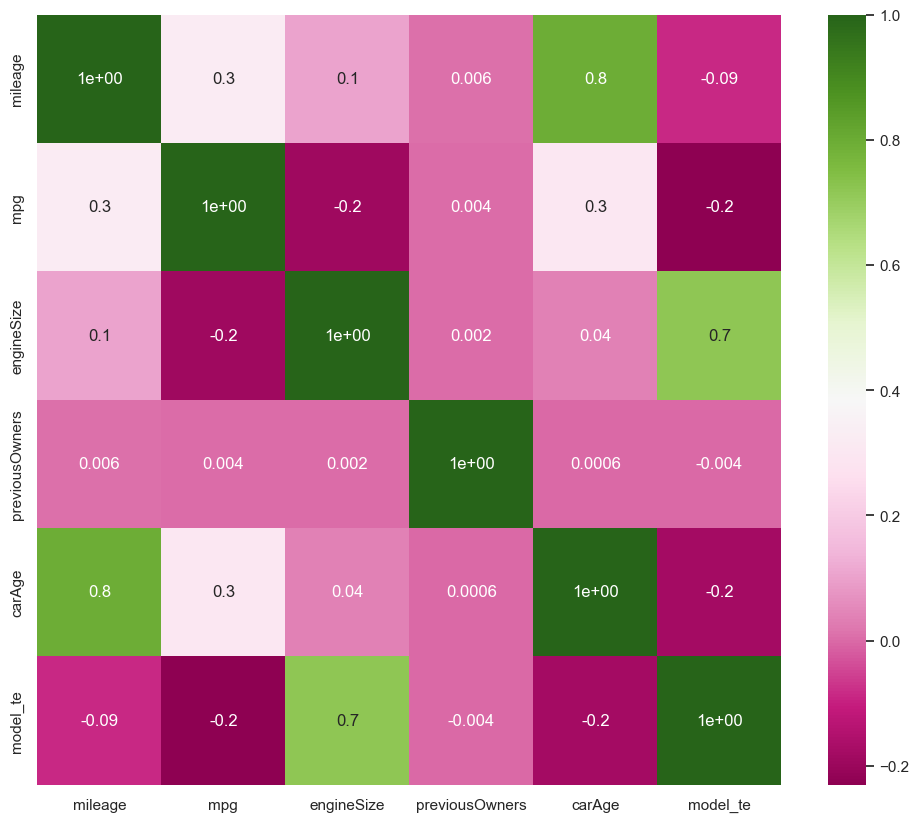

In [181]:
cor_heatmap(cor_spearman)

As we can observe, we can take some useful insights from these visualization. At first, we can see that `previousOwners` is almost not correlated with any of the other features meaning that these variable is independent and that could bring useful and not redundant information to the model.

We easily see that the highest correlation value that we have is `0.8`, which is quite high, between `carAge` and `mileage`. This value makes a lot of sence in a business prespective, because it is expected that while a car is becoming older, ias also increasing the number of miles traveled. Since these two features could bring redundant information for our model, we will take this in consideration.

We also find that `engineSize`and `model_te` have quite high correlation value (0.7) which is, again, expected in a business prespective because, since the model_te is encoded by the target (`price`), bigger engines should be more expensive then smaller ones.

Taking all these insights into consideration, we can proceed to the next method so that in the end we can take action on what features to choose.

`Chi-Square Test` 

Assesses association between **categorical predictors** (one-hots) and a **discretized** target.
If any variable is independent from the target, then it does not contribute for our model. in the other hand, if it is dependent on the target, it does contribute for our model.

Here we crosstab one-hots vs. `y_train` directly as counts to flag informative categories.

**Chi Squared Test**

The implemented function constructs a contingency table between the target variable and each binary indicator representing a category, and then performs the chi-squared test to evaluate whether the two variables are statistically dependent.

If the resulting p_value is below the chosen significance level (0.05), we reject the null hypothesis of independence and conclude that the category is significantly associated with the target. In this case, the feature is labelled as important for prediction. Conversely, if the p_value exceeds the threshold, there is no statistical evidence of dependence, and the feature is considered not important, suggesting that it may be removed from the model.

In [182]:
for var in encoded_features:
    TestIndependence(X_train[var], y_train, var)

Brand_audi is IMPORTANT for Prediction
Brand_bmw is IMPORTANT for Prediction
Brand_ford is IMPORTANT for Prediction
Brand_hyundai is NOT an important predictor. (Discard Brand_hyundai from model)
Brand_mercedes-benz is IMPORTANT for Prediction
Brand_opel is IMPORTANT for Prediction
Brand_skoda is NOT an important predictor. (Discard Brand_skoda from model)
Brand_toyota is IMPORTANT for Prediction
Brand_volkswagen is IMPORTANT for Prediction
transmission_automatic is IMPORTANT for Prediction
transmission_manual is IMPORTANT for Prediction
transmission_semi-auto is IMPORTANT for Prediction
fuelType_diesel is IMPORTANT for Prediction
fuelType_hybrid is IMPORTANT for Prediction
fuelType_petrol is IMPORTANT for Prediction
tax_bin_0 is IMPORTANT for Prediction
tax_bin_101_170 is IMPORTANT for Prediction
tax_bin_171_450 is IMPORTANT for Prediction
tax_bin_1_100 is IMPORTANT for Prediction
tax_bin_451_plus is IMPORTANT for Prediction


As we can see from the output above, there are some features that are not considererd as important to predict the target, such as `Brand_hyndai`and `Brand_skoda`.

### 4.2 Wrapper Methods

In this section, we are going to start applying the RFE (Recursive Feature Elimination) with `Linear Regression` as a base model to determine the best number of features for our model, based on MAE (Mean Absolute Error). 

Then, we built a plot to better understand on what number of features does our score improve the most, to help us make the decision on the best number of features to include in our model.

And then, finnally, we used **RandomForest + RFE** to actually see what are the most important features for our model.

**RFE**

First, we had to decide how many features we wanted to be tested, and we included all of them. In each iteration, a Linear Regression model is instantiated and used as the base estimator for the RFE. This estimater allows calculate coefficients and, consequently, the relative importance of each variable. Then, RFE is applied on train to select the `n_features_to_select`(number of features to select) and them fitted either on train and validation. In the end, the model is trained only with the selected features and predictions are generated. Since we applied the logathmic conversion, we have ro reverse this so that the metrics could have a real meaning. The MAE is calculated separately for training and validation. The validation MAE is used as the main metric for comparing different numbers of features. The process maintains the lowest observed validation MAE and the respective number of variables. In the end, it returns the optimal number of features and their corresponding mean absolute error.

In [183]:
# nof of features
nof_list = np.arange(1, len(all_features) + 1)
high_score = float('inf')
#Variable to store the optimum features
nof = 0
train_score_list = []
val_score_list = []

for n in range(len(nof_list)):

    model = LinearRegression()

    rfe = RFE(estimator=model, n_features_to_select=nof_list[n])
    
    X_train_rfe = rfe.fit_transform(X_train[all_features], y_train)
    X_val_rfe = rfe.transform(X_val[all_features])
    
    model.fit(X_train_rfe, y_train)


    y_pred_train = model.predict(X_train_rfe)

    y_train_real = np.expm1(y_train)
    y_pred_train_real = np.expm1(y_pred_train)

    train_score = mean_absolute_error(y_train_real, y_pred_train_real)
    train_score_list.append(train_score)


    y_pred_val = model.predict(X_val_rfe)

    y_val_real = np.expm1(y_val)
    y_pred_val_real = np.expm1(y_pred_val)

    val_score = mean_absolute_error(y_val_real, y_pred_val_real)
    val_score_list.append(val_score)

    #check best score
    if(val_score <= high_score):
        high_score = val_score
        nof = nof_list[n]
print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))


Optimum number of features: 26
Score with 26 features: 2170.163310


As we can see above, the optimal number of features and its respective MAE for the Linear regression is...
Now, let's build a plot to help us understand on which points did the score decreased the most.

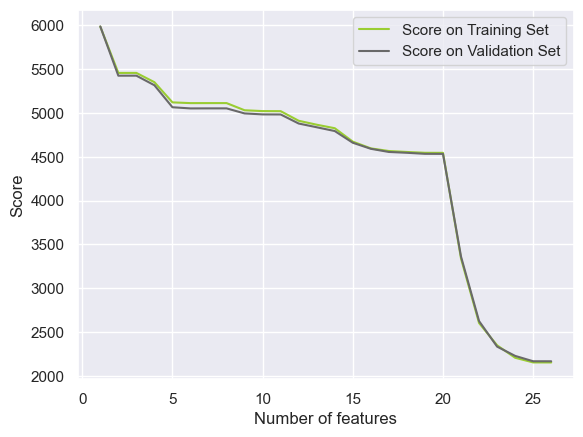

In [184]:
plt.plot(nof_list, train_score_list, label="Score on Training Set", color="yellowgreen")
plt.plot(nof_list, val_score_list,   label="Score on Validation Set", color="dimgray")

plt.xlabel("Number of features")
plt.ylabel("Score")
plt.legend()
plt.show()


As we can see here, the decrease od the MAE score is very little when we start having 22+ features.

So, taking this into consideration, the number of features to select in the next function will be 22.

The estimator we are going to use is a `simple random forest regressor` with not many parameters so it is computational lighter. In the future we will do some hyperparameters tunning. We are also using the RFE method to choose our 22 best features.

In [185]:
estimator = RandomForestRegressor(
            max_depth = 25,
            min_samples_split = 10,        
            max_features = 0.5,
            random_state = 42,
            n_jobs = -1)

selector = RFE(
    estimator=estimator,
    n_features_to_select=22,   
    step=1,
    verbose=1
)

selector.fit(X_train[all_features], y_train)

selected_features = X_train[all_features].columns[selector.support_]
print("Selected features:", selected_features)

y_pred = estimator.fit(X_train[selected_features], y_train).predict(X_val[selected_features])
y_pred = np.expm1(y_pred)
y_val_not_log = np.expm1(y_val)
print("Validation MAE:", mean_absolute_error(y_val_not_log, y_pred))

Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Selected features: Index(['mileage', 'mpg', 'engineSize', 'previousOwners', 'carAge', 'model_te',
       'Brand_audi', 'Brand_ford', 'Brand_mercedes-benz', 'Brand_opel',
       'Brand_skoda', 'Brand_toyota', 'Brand_volkswagen',
       'transmission_automatic', 'transmission_manual',
       'transmission_semi-auto', 'fuelType_diesel', 'fuelType_hybrid',
       'fuelType_petrol', 'tax_bin_101_170', 'tax_bin_171_450',
       'tax_bin_1_100'],
      dtype='object')
Validation MAE: 1238.7638712709731


As we can see, the `best 22 features selected` are : mileage, mpg, engineSize, previousOwners, carAge, model_te, Brand_audi, Brand_ford ,Brand_mercedes-benz, Brand_opel, Brand_skoda, Brand_toyota, Brand_volkswagen, transmission_automatic, transmission_manual, transmission_semi-auto, fuelType_diesel, fuelType_hybrid, fuelType_petrol, tax_bin_101_170, tax_bin_171_450, tax_bin_1_100.

With these features, for this RFR model, the MAE is 1238.763871270973

### 4.3 Embedded Methods

`Lasso`

We apply the Lasso regression (L1-regularized linear model), a widely used embedded technique that drives the coefficients of less important features toward zero. This makes Lasso particularly suitable for feature selection, especially after scaling and in the presence of multicollinearity. By examining the magnitude and sparsity of the learned coefficients, we can determine which features contribute meaningfully to the prediction task and which can be safely removed from the model.

At first, we define the regressor and fit them to the train dataset.

In [186]:
reg = Lasso(alpha =0.001)
reg.fit(X_train[all_features], y_train)

Lasso(alpha=0.001)

Then, let's see how many features did lasso pick as important for our model.

In [187]:
coef = pd.Series(reg.coef_, index = X_train[all_features].columns)
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 19 variables and eliminated the other 7 variables


19 features were selected out of 26, so we should take those 7 in consideration. Let´s see what were the features selected and eleminated by checking the coeficients.

In [188]:
coef.sort_values()

carAge                   -0.296689
Brand_opel               -0.142462
mileage                  -0.135665
Brand_toyota             -0.118766
transmission_manual      -0.118476
Brand_hyundai            -0.086695
Brand_skoda              -0.047833
mpg                      -0.035970
fuelType_petrol          -0.031582
tax_bin_1_100            -0.001657
tax_bin_171_450           0.000000
tax_bin_0                -0.000000
fuelType_diesel          -0.000000
transmission_automatic    0.000000
tax_bin_451_plus         -0.000000
previousOwners            0.000000
Brand_ford                0.000000
tax_bin_101_170           0.004506
transmission_semi-auto    0.008902
Brand_volkswagen          0.020813
Brand_bmw                 0.021587
Brand_mercedes-benz       0.045866
Brand_audi                0.094933
engineSize                0.176969
fuelType_hybrid           0.189696
model_te                  0.241628
dtype: float64

As we can see, from this method, we should remove **tax_bin_171_450 , tax_bin_0 , fuelType_diesel, transmission_automatic,tax_bin_451_plus, previousOwners and Brand_ford**.               

We also built a importance plot showing  the coeficients and the feature importance in a easier way.

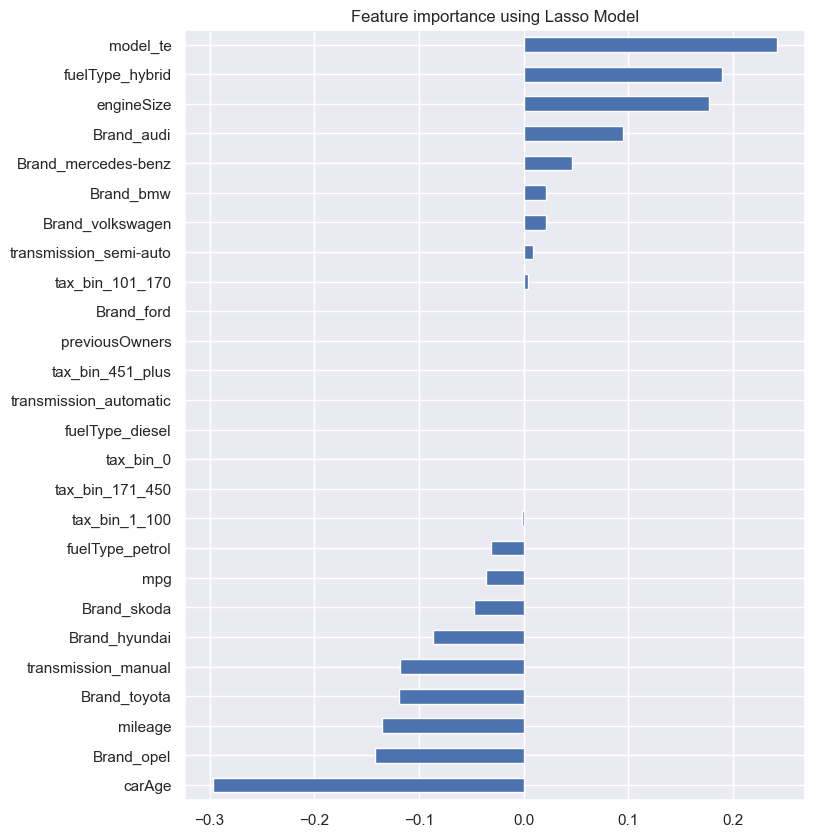

In [189]:
plot_importance(coef,'Lasso')

We can easily observe that model_te and carAge are the most importat features, according to this method. There are also some features that almost are not important for the model, having a coefficient close to 0.

### Extra-Trees ###

In this section, we are going to build a plot with the `ExtraTressRegressor` as the base model to measure the the feature importance (%). The % treshold we are going to define is based on the number of features. Since we have 26 features, we defined the treshold like this:
    
                                                (100/number of features)/2

So, the treshold we are going to use is **1.9** .

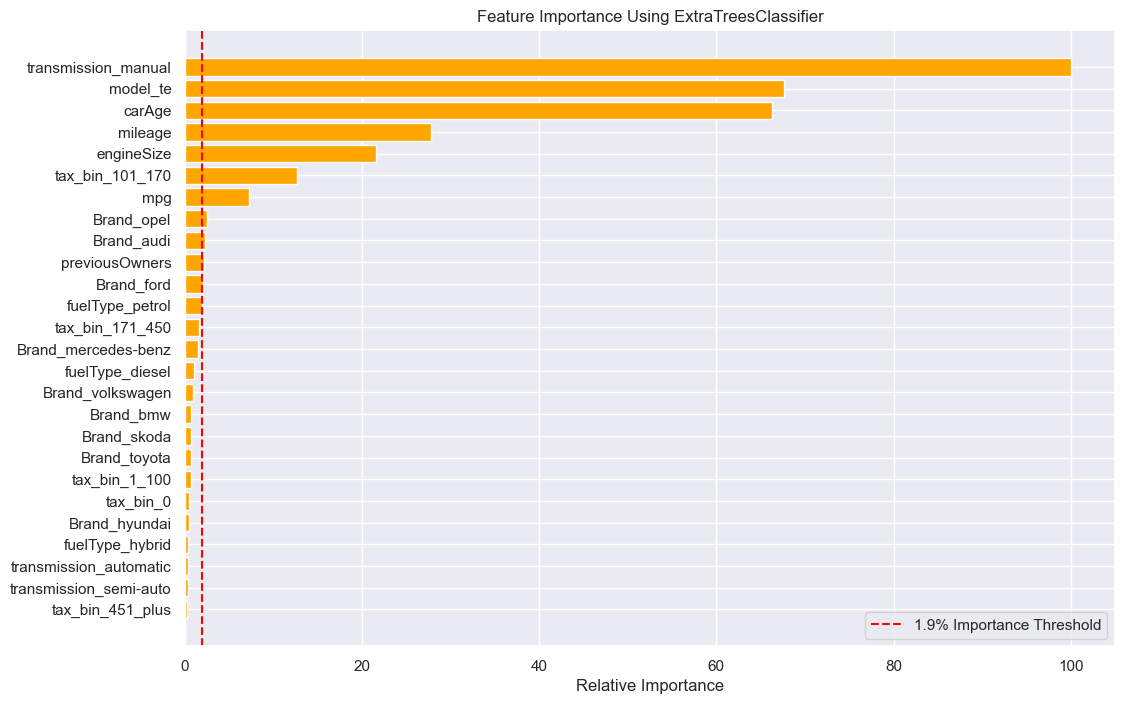


Initial Features: 26

['mileage', 'mpg', 'engineSize', 'previousOwners', 'carAge', 'model_te', 'Brand_audi', 'Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes-benz', 'Brand_opel', 'Brand_skoda', 'Brand_toyota', 'Brand_volkswagen', 'transmission_automatic', 'transmission_manual', 'transmission_semi-auto', 'fuelType_diesel', 'fuelType_hybrid', 'fuelType_petrol', 'tax_bin_0', 'tax_bin_101_170', 'tax_bin_171_450', 'tax_bin_1_100', 'tax_bin_451_plus']

Important Numerical Features:
['mileage', 'mpg', 'engineSize', 'previousOwners', 'carAge', 'model_te']

Important Categorical Features:
['Brand_audi', 'Brand_ford', 'Brand_opel', 'transmission_manual', 'fuelType_petrol', 'tax_bin_101_170']


In [190]:
plot_feature_importance(X_val[numeric], X_val[categ_features],y_val, 250, 42, 1.9)

Above, we can see al the features that were selected using this method. With the treshold defined, 12 features were selected as important for our model.

Now, we are going to proceed to the most important feature selection section, in which we store all the results that we got above, and take a decision if we should or should not use each feature.

### 4.4 Final Features

Consolidation table below summarizes **signals across methods** and a pragmatic decision (keep / drop / try both).


| Predictor              | Spearman  | RFE   | Lasso   | Chi-Square | Extra-Trees | What to do? (One possible way to "solve") |
|------------------------|-----------|---------|---------|------------|-------------|-------------------------------------------|
| model_te               | Keep      | Keep    | Keep    | -          | Keep        | Keep                                      |
| engineSize             | Keep      | Keep    | Keep    | -          | Keep        | Keep                                      |
| mileage                | Keep      | Keep    | Keep    | -          | Keep        | Keep                                      |
| carAge                 | Choose between 'carAge' and 'mileage'      | Keep        | Keep    | Keep | Keep       | Try with and without        |
| mpg                    | Keep      | Keep    | Keep    | -          | Keep        | Keep                                      |
| previousOwners         | Discard   | Keep    | Discard | -          | Keep        | Try with and without                      |
| paintQuality%          | -         | -       | -       | -          | -           | Discard                                   |
| hasDamage              | -         | -       | -       | -          | -           | Discard                                   |
| Brand_audi             | -         | Keep    | Keep    | Keep       | Keep        | Keep                                      |
| Brand_ford             | -         | Keep    | Discard | Keep       | Keep        | Try with and without                      |
| Brand_volkswagen       | -         | Keep    | Keep    | Keep       | Discard     | Try with and without                      |
| Brand_mercedes-benz    | -         | Keep    | Keep    | Keep       | Discard     | Try with and without                      |
| Brand_hyundai          | -         | Discard | Keep    | Discard    | Discard     | Try with and without                      |
| Brand_bmw              | -         | Discard | Keep    | Keep       | Discard     | Try with and without                      |
| Brand_skoda            | -         | Keep    | Keep    | Discard    | Discard     | Try with and without                      |
| Brand_opel             | -         | Keep    | Keep    | Keep       | Keep        | Keep                                      |
| Brand_toyota           | -         | Keep    | Keep    | Keep       | Discard     | Try with and without                      |
| tax_bin_0              | -         | Discard | Discard | -          | Discard     | Discard                                   |
| tax_bin_1_100          | -         | Keep    | Keep    | -          | Discard     | Try with and without                      |
| tax_bin_101_170        | -         | Keep    | Keep    | -          | Keep        | Try with and without                      |
| tax_bin_171_450        | -         | Keep    | Discard | -          | Discard     | Try with and without                      |
| tax_bin_451_plus       | -         | Discard | Discard | -          | Discard     | Discard                                   |
| transmission_manual    | -         | Keep    | Keep    | Keep       | Keep        | Keep                                      |
| transmission_semi-auto | -         | Keep    | Keep    | Keep       | Discard     | Try with and without                      |
| transmission_automatic | -         | Keep    | Discard | Keep       | Discard     | Try with and without                      |
| fuelType_hybrid        | -         | Keep    | Keep    | Keep       | Discard     | Try with and without                      |
| fuelType_diesel        | -         | Keep    | Discard | Keep       | Discard     | Try with and without                      |
| fuelType_petrol        | -         | Keep    | Keep    | Keep       | Keep        | Keep                                      |




If we should keep a feature according to every method used, we made the decision to keep the feature. If we should remove a feature according to every method used, we Discard that feature. If we should keep a feature for some methods and Discard for others, we decided to try modeling with and without that feature.

Based on this, we created 2 lists, keep (for the ones that all methods kept the feature) , and optional (for the ones to try with and without).

In [191]:
keep = ['model_te', 'engineSize', 'Brand_opel', 'mpg', 'transmission_manual', 'mileage', 'Brand_audi', 'fuelType_petrol']

In [192]:
optional = [
 'carAge',
 'previousOwners',
 'Brand_ford',
 'Brand_volkswagen',
 'Brand_mercedes-benz',
 'Brand_hyundai',
 'Brand_bmw',
 'Brand_skoda',
 'Brand_toyota',
 'tax_bin_101_170', 
 'tax_bin_171_450', 
 'tax_bin_1_100',
 'transmission_semi-auto',
 'transmission_automatic',
 'fuelType_diesel',
 'fuelType_hybrid',
   ]

After creating both lists, we created a function that makes the backward elemination features. Basically, this function requires a model, which we chose the one that was giving us the best results in the "Modeling" notebook and then it goes, feature by feature, eliminating each one by each iteration and, if the MAE improves, it definitely removes that feature. If the MAE does not improve, it keeps the feature. Every iterantion, it gives us the feature that weas tested and the MAE value got in that iteration. In the end, it gives us the full list of features to keep. Here, we used a more complex model so that the features selected would fit better in the future models tested.

In [193]:
def backward_elimination(X, y_log, keep, optional):

    def evaluate(features):
        X_sel = X_train[features]
        X_features = X[features]
        model = HistGradientBoostingRegressor(
            learning_rate = 0.05,
            max_iter = 990,
            max_depth = 14,
            min_samples_leaf = 18,
            max_leaf_nodes = 70,
            max_bins = 255,
            l2_regularization = 0,       
            early_stopping = False,    
            validation_fraction = 0.5,
            n_iter_no_change = 10,
            random_state = 42
            )
        model.fit(X_sel, y_train)
        preds = model.predict(X_features)
        preds = np.expm1(preds)
        y = np.expm1(y_log)
        return mean_absolute_error(y, preds)

    # baseline: all features
    current_features = keep + optional
    best_mae = evaluate(current_features)

    print("Baseline TRAIN MAE:", best_mae)

    # backward elimination
    for feat in optional.copy():

        candidate_features = current_features.copy()
        candidate_features.remove(feat)

        mae = evaluate(candidate_features)

        if mae <= best_mae:
            print(f"Removing {feat} improved VAL MAE: {best_mae} → {mae}")
            best_mae = mae
            current_features.remove(feat)
            optional.remove(feat)
        else:
            print(f"Keeping {feat} (VAL MAE got worse: {mae})")

    print("\nFinal selected features :")
    print(current_features)

    return current_features

Then, we just need to call our function and choose to evaluate on validation dataset.

In [194]:
selected = backward_elimination(
    X_val,
    y_val,
    keep=keep,
    optional=optional
)

Baseline TRAIN MAE: 1220.520023794832
Keeping carAge (VAL MAE got worse: 1497.9196888648898)
Removing previousOwners improved VAL MAE: 1220.520023794832 → 1212.1351180220952
Removing Brand_ford improved VAL MAE: 1212.1351180220952 → 1209.2428506347003
Keeping Brand_volkswagen (VAL MAE got worse: 1210.822907347611)
Keeping Brand_mercedes-benz (VAL MAE got worse: 1219.1397419864359)
Keeping Brand_hyundai (VAL MAE got worse: 1209.6279662657173)
Keeping Brand_bmw (VAL MAE got worse: 1219.0500843529803)
Removing Brand_skoda improved VAL MAE: 1209.2428506347003 → 1208.247427798434
Removing Brand_toyota improved VAL MAE: 1208.247427798434 → 1205.5919249485528
Keeping tax_bin_101_170 (VAL MAE got worse: 1209.7741539394922)
Keeping tax_bin_171_450 (VAL MAE got worse: 1206.286986297602)
Keeping tax_bin_1_100 (VAL MAE got worse: 1209.2534896625975)
Keeping transmission_semi-auto (VAL MAE got worse: 1210.3101937089953)
Keeping transmission_automatic (VAL MAE got worse: 1209.2483469096994)
Keeping 

In [195]:
selected

['model_te',
 'engineSize',
 'Brand_opel',
 'mpg',
 'transmission_manual',
 'mileage',
 'Brand_audi',
 'fuelType_petrol',
 'carAge',
 'Brand_volkswagen',
 'Brand_mercedes-benz',
 'Brand_hyundai',
 'Brand_bmw',
 'tax_bin_101_170',
 'tax_bin_171_450',
 'tax_bin_1_100',
 'transmission_semi-auto',
 'transmission_automatic',
 'fuelType_diesel',
 'fuelType_hybrid']

To finnish this notebook, these are the final features selected for modeling.

Our final features are : **-'model_te',**
    **-'engineSize',**
    **-'Brand_opel',**
    **-'mpg',**
    **-'transmission_manual',**
    **-'mileage',**
    **-'Brand_audi',**
    **-'fuelType_petrol',**
    **-'carAge',**
    **-'Brand_volkswagen',**
    **-'Brand_mercedes-benz',**
    **-'Brand_hyundai',**
    **-'Brand_bmw',**
    **-'tax_bin_101_170',**
    **-'tax_bin_171_450',**
    **-'tax_bin_1_100',**
    **-'transmission_semi-auto',**
    **-'transmission_automatic',**
    **-'fuelType_diesel',**
    **-'fuelType_hybrid'`**

Then, we just need to export the updated csv files to import in the "Modeling" notebook.

In [196]:
X_train_filtered = X_train[selected]
X_val_filtered = X_val[selected]
test_filtered = test_encoded[['carID'] + selected]

# 5. Export

In [197]:
X_train_filtered.to_csv('../project_data/X_train_filtered_data_KNN.csv')
y_train.to_csv('../project_data/y_train_data_KNN.csv')

X_val_filtered.to_csv('../project_data/X_val_filtered_data_KNN.csv')
y_val.to_csv('../project_data/y_val_data_KNN.csv')

test_filtered.to_csv('../project_data/test_filtered_data_KNN.csv')